Động lực giảm chiều

- Khó trực quan hóa khi $p$ > 3
- Nhiều chiều tương quan gây khó cho thuật toán
- Tính toán trở nên tốn kém

"Curse of dimensionality"

- cần rất nhiều data để mô tả distribution
- khoảng cách giữa các data points dần mất ý nghĩa

Mục tiêu khi giảm chiều dữ liệu: giảm chiều nhưng vẫn giữ cấu trúc chính

# Principal Component Analysis (PCA)
Cách đơn giản nhất để giảm chiều dữ liệu từ $D$ về $K<D$ là chỉ giữ lại $K$ phần tử quan trọng nhất. Tuy nhiên, chúng ta chưa xác định được thành phần nào là quan trọng hơn, hoặc trong trường hợp xấu nhất, lượng thông tin mà mỗi thành phần mang là như nhau và bỏ đi thành phần nào cũng dẫn đến việc mất một lượng lớn thông tin. Thay vào đó, nếu chúng ta biểu diễn các vector dữ liệu ban đầu trong một hệ cơ sở mới mà trong hệ cơ sở mới đó, tầm quan trọng giữa các thành phần là khác nhau rõ rệt, thì chúng ta có thể bỏ qua những thành phần ít quan trọng nhất. 

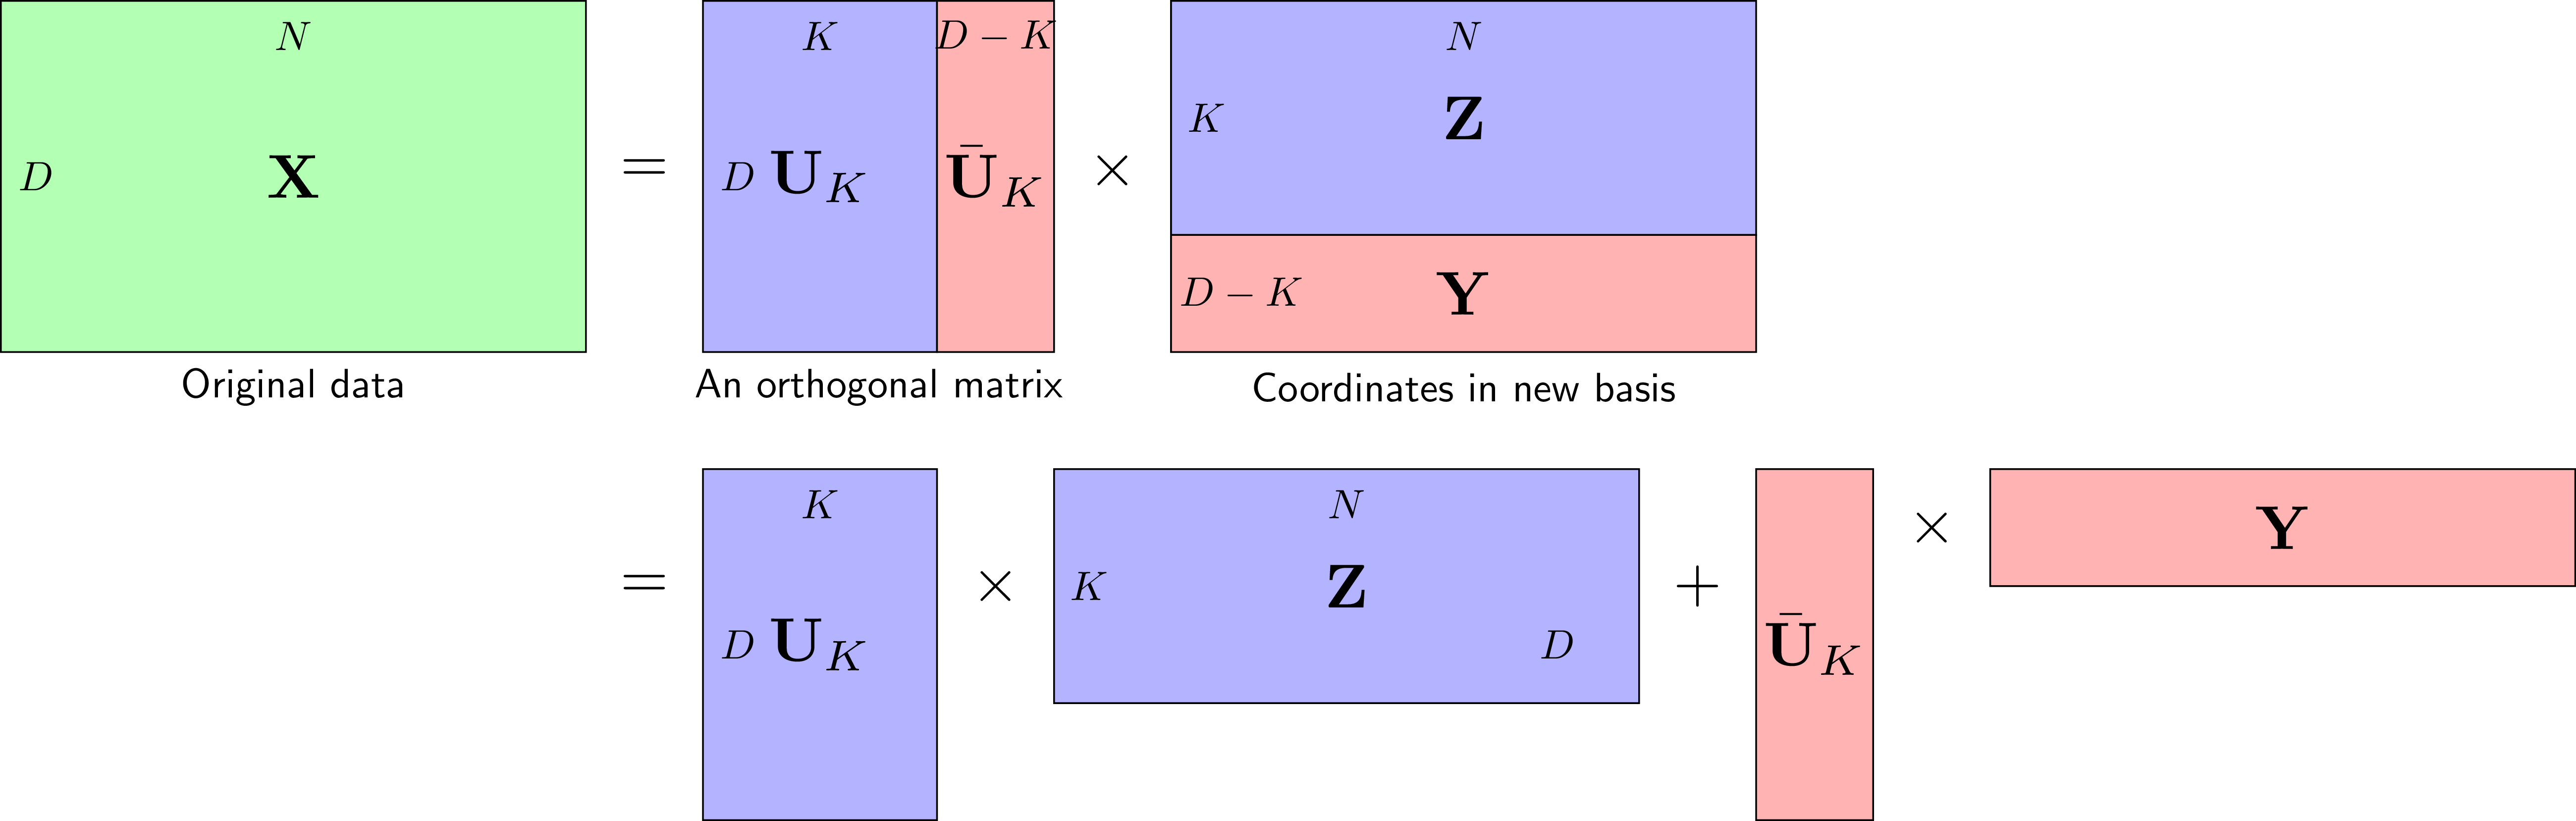
$\rightarrow$ PCA là pp tìm một hệ trực chuẩn mới sao cho trong hệ này, các thành phần quan trọng nhất nằm trong $K$ thành phần đầu tiên.
First principal component (first PC) là tổ hợp tuyến tính của các biến đã chuẩn hóa trung bình

$$Z_1 = \sum^p_{j=1}\phi_{j1}(X_j - \={X_j})$$

Trong đó:

- $\phi{j1}$: hệ số tải - loading - mỗi biến gốc đóng góp bao nhiêu
- $z_{i1}$: điểm PC (score) - tọa độ mới của observation $i$
- PC thứ $m$ vuông góc với mọi PC trước: $\sum_j \phi_{jm} \phi_{jk} = 0$ với $k<m$

## Bài toán tối ưu PCA

Tìm hệ số tải $\phi_1 = (\phi_{11}, ..., \phi_{p1})$ sao cho phương sai hình chiếu lớn nhất
$$max_{\phi_1} = \frac 1 n \sum^n_{i=1} z^2_{i1} \ s.t \sum^p_{j=1}\phi^2_{j1}=1$$

Vì sao cần phải ràng buộc $||\phi_1||=1$: để chuẩn hóa tách "hướng" khỏi biên độ

Triển khai $z_{i1}=\phi_1^{\top}(\mathbf x_i - \mathbf {\={x})}$:

$$\frac 1 n \sum_i z^2_{i1} = \frac 1 n \sum_i \phi^{\top}_1 (\mathbf x_i - \mathbf{\={x}})(\mathbf x_i - \mathbf{\={x}})^{\top}\phi_1=\phi^{\top}_1 \mathbf S \phi_1$$

với ma trận hiệp phương sai mẫu $\mathbf S = \frac 1 n \sum_i (\mathbf x_i - \mathbf{\={x}})(\mathbf x_i - \mathbf{\={x}})^{\top}$ (cỡ $p\times p$ symmetric, semi-positive)

Từ đó bài toán trở thành:
$$max_{\phi_1}\phi^{\top}_1 \mathbf S \phi_1 \ s.t\ \phi^{\top}_1\phi_1 = 1$$

Giải bằng Lagrangian

$$L(\phi_1, \lambda) = \phi^{\top}_1 \mathbf S \phi_1 - \lambda (\phi ^{\top}_1 \phi_1 - 1)$$

Điều kiện dừng $\partial L / \partial \phi_1 = 0$:
$$2\mathbf S \phi_1 - 2\lambda \phi_1 = 0 \leftrightarrow \mathbf S\phi_1 = \lambda \phi_1$$

- $\phi_1$ là vector riêng của $\mathbf S$, $\lambda$ là trị riêng tương ứng
- Phương sai hình chiếu tại nghiệm: $\phi_1 ^{\top} \mathbf S \phi_1  = \lambda \phi_1^{\top} \phi_1 = \lambda \rightarrow$ phương sai = trị riêng
- Để phương sai lớn nhất $\rightarrow$ chọn $\phi_1$ là vector riêng ứng với trị riêng lớn nhất của $\mathbf S$

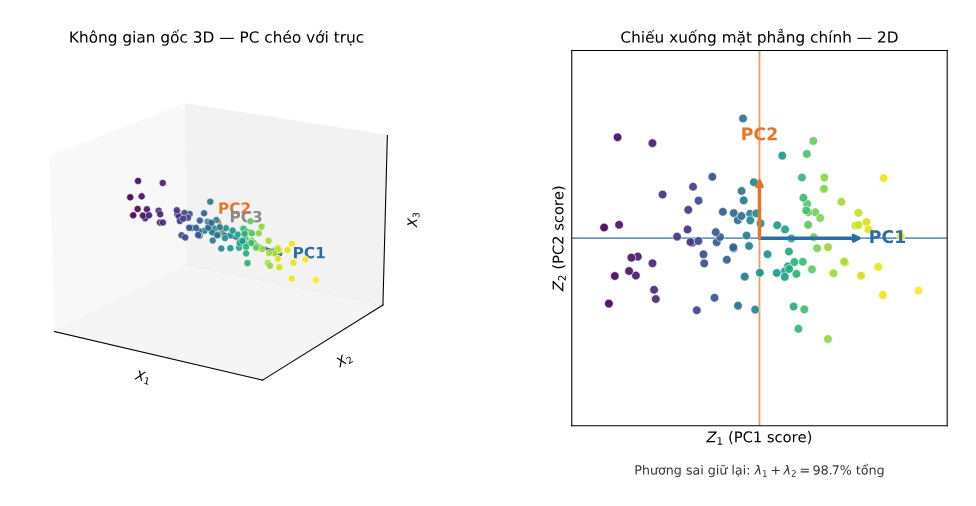

Có thể nói, PCA là phép xoay hệ trục từ ($\mathbf X_1, \mathbf X_2, \mathbf X_3$) sang ($\mathbf Z_1, $\mathbf Z_2$, $\mathbf Z_3$). Trái $\rightarrow$ phải: cùng data, hai góc nhìn.

- Trục mới sắp theo phương sai giảm dần. PC1 dài nhất (phương sai lớn nhất), PC3 ngắn nhất $\rightarrow$ chiều thừa, có thể bỏ $\rightarrow$ giảm chiều
- Tính chất hệ trục PC: Các PC trực giao đôi một và không tương quan tức $Cov(Z_i, Z_j) = 0, i\ne j$, khác với $X_1, X_2, X_3$ vốn có tương quan.

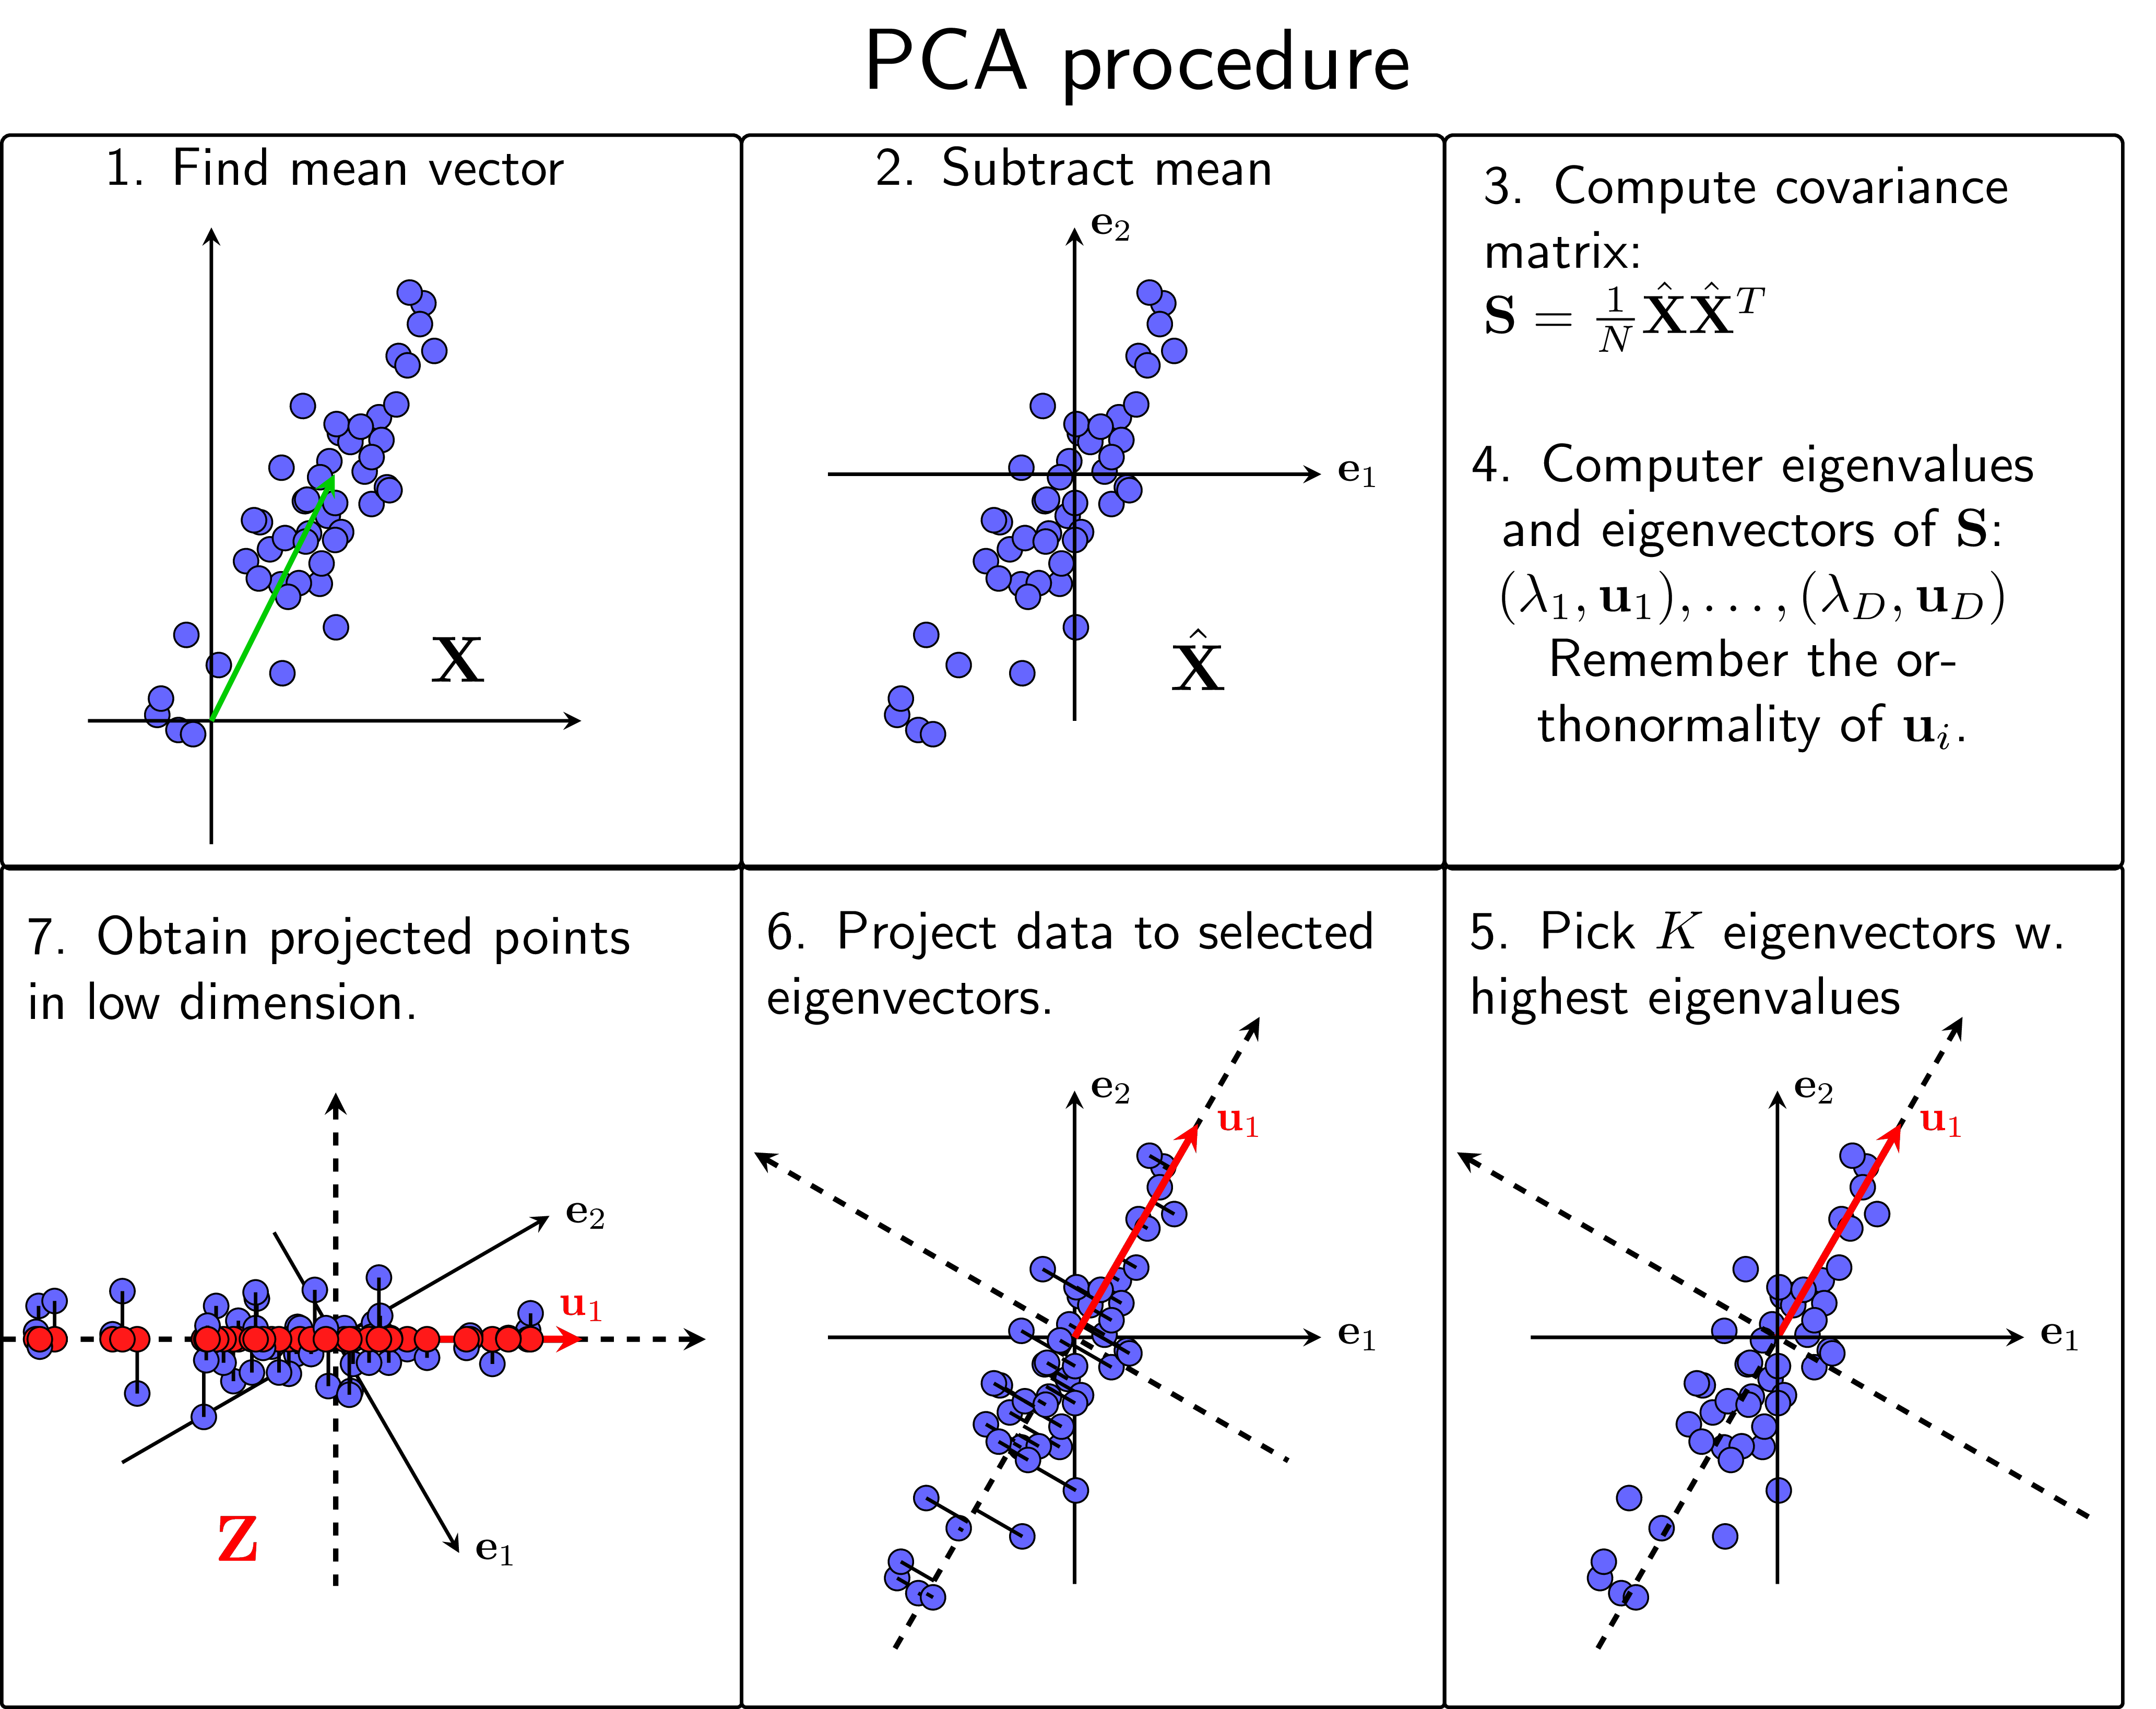

1. Tính vector kỳ vọng của toàn bộ dữ liệu: $\={\mathbf x}=\frac 1 N \sum^N_{n=1}\mathbf x_n$
2. Trừ mỗi điểm dữ liệu đi vector kỳ vọng của toàn bộ dữ liệu: $\hat {\mathbf x} = \mathbf x_n - \mathbf {\={x}}$
3. Tính ma trận hiệp phương sai: $\mathbf S = \frac 1 N \mathbf {\hat X \hat X^{\top}}$
4. Tính các trị riêng và vector riêng có norm bằng 1 của ma trận này, sắp xếp chúng theo thứ tự giảm dần của trị riêng
5. Chọn $K$ vector riêng tương ứng với $K$ trị riêng lớn nhất để xây dựng ma trận $\mathbf U_k$ có các cột tạo thành một hệ trực giao. $K$ vectors này, còn được gọi là các thành phần chính, tạo thành một không gian con gần với phân bố của dữ liệu ban đầu đã chuẩn hóa. 
6. Chiếu dữ liệu ban đầu đã chuẩn hóa $\mathbf {\hat X}$ xuống không gian con tìm được
7. Dữ liệu mới chính là tọa đổ của các điểm dữ liệu trên không gian mới $\mathbf Z = \mathbf U^{\top}_K \mathbf{\hat X}$
Dữ liệu ban đầu có thể được tính xấp xỉ theo dữ liệu mới sau đây $\mathbf x \approx \mathbf U_K\mathbf Z + \mathbf {\={x}}$

## Cách chọn $K$ thành phần chính

Tỷ lệ phương sai được giải thích (PVE):
$$PVE_m = \frac {Var(Z_m)}{\sum^p_{j=1}Var(X_j)}$$

- Trực quan hóa: thường chọn 2 hoặc 3 PC
- Tiền xử lý: chọn $k$ sao cho PVE tích lũy đủ lớn
- Tìm điểm khuỷu trên scree plot
- Nếu dùng cho dự đoán: có thể chọn $k$ bằng kiểm định chéo (cross-validation)
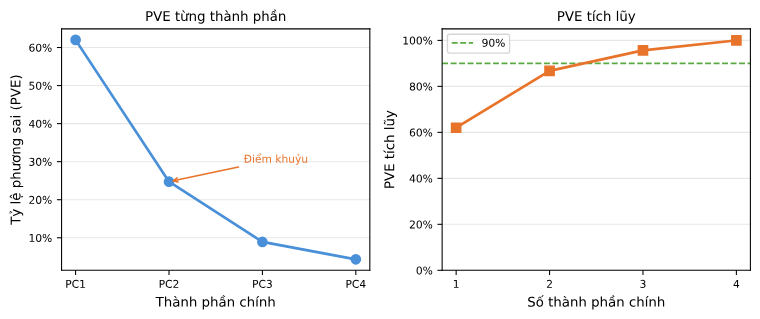


# Multidimensional Scaling (MDS)
MDS is a visual representation of distances or dissimilarities between sets of objects. PCA là phép chiếu tuyến tính - không thể "mở" cấu trúc phi tuyến (xoắn ốc, đa tạp cong)

- Các điểm xa nhau theo cấu trúc thực có thể bị chiếu chồng lên nhau
- MDS bảo toàn khoảng cách thay vì phương sai $\rightarrow$ không bị giới hạn bởi phép chiếu tuyến tính

Tìm $z_1,...,z_N\in \mathbb R^k$ sao cho khoảng cách chiều thấp xấp xỉ khoảng cách gốc. Gọi $d_{ii'}$ là khoảng cách gốc, $||z_i-z_{i'}||$ là khoảng cách chiều thấp. Kruskal-shepard cực tiểu hóa:
$$\underset{z_1,...,z_N}{min}\sum_{i \ne i'}(d_{ii'}-||z_i-z_{i'}||)^2$$
Mọi cặp điểm đầu quan trọng như nhau, dù gần hay xa

## Sammon mapping

Cực tiểu hóa với trọng số ưu tiên cặp gần
$$\underset{z_1,...,z_N}{min}\sum_{i\ne i'}\frac {(d_{ii'}-||z_i-z_{i'}||)^2}{d_{ii'}}$$

Chia cho $d_{ii'}$ cặp gần nhau ($d_{ii'}$) bị phạt nặng hơn khi sai lệch $\rightarrow$ bảo toàn cấu trục cục bộ tốt hơn

## Quan hệ giữa MDS và PCA

Kruskal-Shepard và Sammon bảo toàn khoảng cách. Nếu thay bằng bảo toàn tích vô hướng:
$$\underset{z_1,...,z_N}{min}\sum_{i,i'}(<x_i-\={x},x_{i'}-\={x}>-<z_i - \={z}, z_{i'} - \={z}>)^2$$
Nghiệm của bài toán này chính xác là PCA, chiếu lên $k$ vector riêng đầu tiên. PCA là trường hợp đặc biệt của MDS. Nhưng MDS tổng quát hơn, chỉ cần ma trận khoảng cách, không cần dữ liệu gốc

## Non-metric MDS

Kruskal-Shepard và Sammon cần giá trị chính xác khoảng cách. Non-metric MDS chỉ cần thứ hạng: nếu $d_{ab}\le d_{cd}$ trong gốc thì cũng muốn $||z_a - z_b|| \le ||z_c - z_d||$ trong chiều thấp

$$\underset{z_i,\theta}{min}\frac {\sum_{i\ne i'}(||z_i-z_{i'}|| - \theta(d_{ii'}))^2}{\sum_{i\ne i'}||z_i - z_{i'}||^2}$$

- $\theta$ : hàm tăng đơn điệu bất kỳ - chỉ giữ thứ tự, không cần giữ giá trị
- Alternating optimization: cố định $z_i$ tìm $\theta$, rồi cố định $\theta$ tìm $z_i$



# t-SNE

## Nhúng láng giềng ngẫu nhiên (SNE)

MDS bảo toàn khoảng cách giữa mọi cặp điểm. SNE đổi góc nhìn: với mỗi điểm, tính xác suất láng giềng, điểm nào gần thì xác suất cao, xa thì thấp.

- $P$: phân phối xác suất trong không gian gốc
- $Q$: phân phối xác suất trong chiều thấp
- Mục tiêu: tìm tọa độ chiều thấp sao cho $Q\approx P$

## Độ tương đồng cao

Dùng Gaussian quanh mỗi điểm $x_i$
$$p_{j|i}\propto exp(-\frac {||x_j - x_i||^2}{2\sigma_u^2})$$
$$P_i \propto \mathcal N (x_i, \sigma_i^2)$$

- $x_j$ càng gần $x_i,p_{j|i}$ càng lớn
- $\sigma_i$ được chọn theo perplexity

## Chọn perplexity

Chọn $\sigma_i$ sao cho mỗi điểm có perplexity cố định
$$Perp(P_i) = 2^{H(P_i)}$$

- Vùng đặc (nhiều điểm gần) $\rightarrow \sigma_i$ nhỏ
- Vùng thưa (ít điểm gần) $\rightarrow \sigma_i$ lớn
- Perplexity thường dùng: 5-50

## Độ tương đồng chiều thấp

SNE gốc dùng Gaussian trong không gian chiều thấp:
$$q_{j|i}\propto exp(-||z_j - z_i||^2)$$

Hàm mục tiêu:
$$C = \sum_i KL(P_i||Q_i)=\sum_i\sum_j p_{j|i}log\frac {p_{j|i}}{q_{j|i}}$$

- tối thiểu hóa bằng gradient descent

## So sánh phân phối $P_i$ và $Q_i$

Mục tiêu: tìm $z_i$ sao cho $Q_i \approx P_i$ cho mọi điểm i. t-SNE ưu tiên bảo toàn các láng giềng gần.

## Thuật toán T-SNE

1. Tính $P$ từ dữ liệu gốc
2. Khởi tạo ngẫu nhiên các $z_i$
3. Tính $Q$ trong không gian chiều thấp
4. Tối thiểu hóa $KL(P||Q)$

## TLDR

PCA:
- Bảo toàn phương sai toàn cục
- Tham số: số P $k$
$\rightarrow$ tốt cho cấu trúc tuyến tính và tiền xử lý

MDS:
- Bảo toàn khoảng cách
- Tham số: số chiều $k$
Hữu ích khi chỉ có ma trận khoảng cách

T-SNE:
- Bảo toàn láng giềng gần
- Tham số: perplexity mạnh nhất cho trực quan hóa và khám phá cụm
